In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("dermatology_skincare.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample rows:")
display(df.head(5))
print("\nNull values:")
print(df.isnull().sum())

Shape: (1120, 10)

Columns: ['Age_Group', 'Skin_Type', 'Skin_Subtype', 'Sensitivity', 'Concern', 'Internal_Type', 'Ingredients', 'Concentrations', 'Effects', 'Treatment_Profile']

Sample rows:


,Age_Group,Skin_Type,Skin_Subtype,Sensitivity,Concern,Internal_Type,Ingredients,Concentrations,Effects,Treatment_Profile
0,14-18,Normal,Normal to Dry,Yes,Acne,Comedonal,Zinc PCA + Benzoyl Peroxide + Salicylic Acid,2.5% + 2% + 1%,"Controls sebum production, Kills acne-causing ...",Zinc PCA(2.5%) + Benzoyl Peroxide(2%) + Salicy...
1,14-18,Normal,Normal to Dry,Yes,Acne,Inflammatory,Zinc PCA + Benzoyl Peroxide + Niacinamide,2.5% + 5% + 1%,"Controls sebum production, Kills acne-causing ...",Zinc PCA(2.5%) + Benzoyl Peroxide(5%) + Niacin...
2,14-18,Normal,Normal to Dry,Yes,Acne,Fungal,Zinc PCA + Azelaic Acid + Salicylic Acid,10% + 2% + 1%,"Controls sebum production, Reduces acne and im...",Zinc PCA(10%) + Azelaic Acid(2%) + Salicylic A...
3,14-18,Normal,Normal to Dry,Yes,Acne,Cystic,Benzoyl Peroxide + Niacinamide + Azelaic Acid,2.5% + 5% + 10%,"Kills acne-causing bacteria, Reduces inflammat...",Benzoyl Peroxide(2.5%) + Niacinamide(5%) + Aze...
4,14-18,Normal,Normal to Dry,Yes,Dark Circles,Pigmented,Hyaluronic Acid + Caffeine + Vitamin C,1% + 3% + 10%,"Hydrates and plumps the skin, Reduces puffines...",Hyaluronic Acid(1%) + Caffeine(3%) + Vitamin C...



Null values:
Age_Group            0
Skin_Type            0
Skin_Subtype         0
Sensitivity          0
Concern              0
Internal_Type        0
Ingredients          0
Concentrations       0
Effects              0
Treatment_Profile    0
dtype: int64


In [ ]:
def extract_pct(pct_str):
    """Extract float from strings like '2.5%', '10%', '1%'. Returns 0.0 if not found."""
    match = re.search(r'([\d.]+)\s*%', str(pct_str))
    return float(match.group(1)) if match else 0.0

def parse_row_concentrations(ingredients_str, concentrations_str):
    """
    Given:
      ingredients_str  = 'Zinc PCA + Benzoyl Peroxide + Salicylic Acid'
      concentrations_str = '2.5% + 2% + 1%'
    Returns dict: {'zinc_pca': 2.5, 'benzoyl_peroxide': 2.0, 'salicylic_acid': 1.0}
    """
    ingredients = [i.strip().lower().replace(' ', '_').replace('-', '_')
                   for i in str(ingredients_str).split('+')]
    concentrations = [extract_pct(c) for c in str(concentrations_str).split('+')]

    return dict(zip(ingredients, concentrations))

concentration_records = []
for _, row in df.iterrows():
    record = parse_row_concentrations(row['Ingredients'], row['Concentrations'])
    concentration_records.append(record)

conc_df = pd.DataFrame(concentration_records).fillna(0.0)

print(f"Extracted {conc_df.shape[1]} unique ingredient columns")
print("\nIngredient columns:")
print(conc_df.columns.tolist())
print("\nSample (first 5 rows):")
display(conc_df.head())
print("\nNon-zero counts per ingredient (how many rows use each):")
print((conc_df > 0).sum().sort_values(ascending=False))

Extracted 23 unique ingredient columns

Ingredient columns:
['zinc_pca', 'benzoyl_peroxide', 'salicylic_acid', 'niacinamide', 'azelaic_acid', 'hyaluronic_acid', 'caffeine', 'vitamin_c', 'alpha_arbutin', 'lactic_acid', 'green_tea_extract', 'chamomile_extract', 'aloe_vera', 'glycolic_acid', 'licorice_extract', 'kojic_acid', 'tranexamic_acid', 'clay', 'centella_asiatica', 'willow_bark_extract', 'coenzyme_q10', 'peptides', 'retinol']

Sample (first 5 rows):


,zinc_pca,benzoyl_peroxide,salicylic_acid,niacinamide,azelaic_acid,hyaluronic_acid,caffeine,vitamin_c,alpha_arbutin,lactic_acid,...,glycolic_acid,licorice_extract,kojic_acid,tranexamic_acid,clay,centella_asiatica,willow_bark_extract,coenzyme_q10,peptides,retinol
0,2.5,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.5,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,2.5,0.0,5.0,10.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,3.0,10.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Non-zero counts per ingredient (how many rows use each):
niacinamide            640
green_tea_extract      293
vitamin_c              269
salicylic_acid         264
licorice_extract       209
azelaic_acid           205
zinc_pca               203
hyaluronic_acid        172
benzoyl_peroxide       162
alpha_arbutin          149
caffeine               129
aloe_vera               99
tranexamic_acid         56
kojic_acid              55
centella_asiatica       54
glycolic_acid           49
coenzyme_q10            49
clay                    48
lactic_acid             46
chamomile_extract       46
willow_bark_extract     45
retinol                 36
peptides                35
dtype: int64


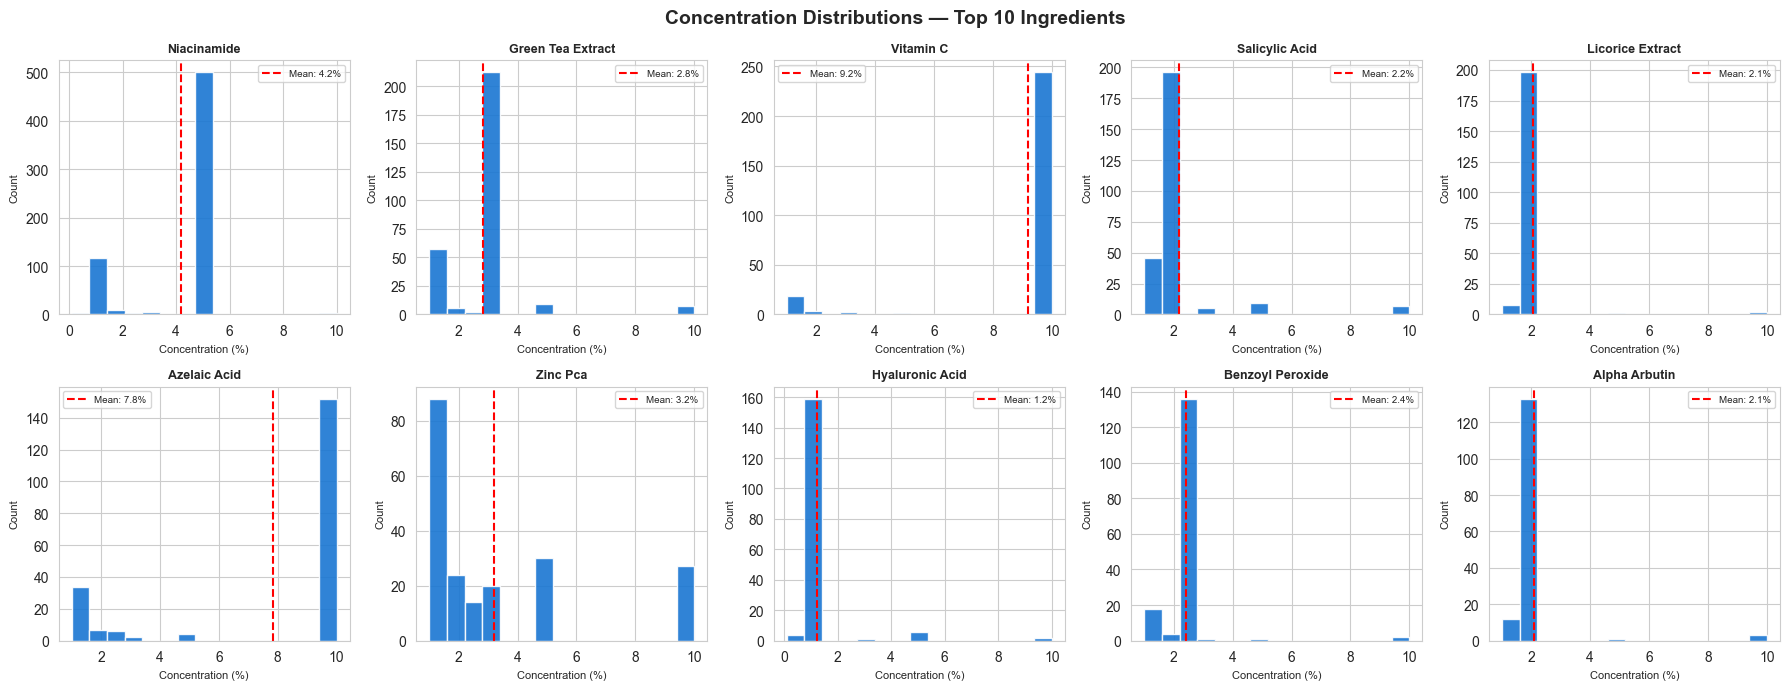

✅ Concentration distribution plot saved.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

top_ingredients = (conc_df > 0).sum().sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Concentration Distributions — Top 10 Ingredients', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, top_ingredients):
    nonzero = conc_df[col][conc_df[col] > 0]
    ax.hist(nonzero, bins=15, color='#1976D2', edgecolor='white', alpha=0.9)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.set_xlabel('Concentration (%)', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.axvline(nonzero.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {nonzero.mean():.1f}%')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('concentration_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Concentration distribution plot saved.')

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'Age_Group',
    'Skin_Type',
    'Skin_Subtype',
    'Sensitivity',
    'Concern',
    'Internal_Type'
]

df_encoded = df[cat_cols].copy()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {le.classes_.tolist()}")

df_ohe = pd.get_dummies(df[cat_cols], columns=cat_cols, drop_first=False)

print(f"\nOne-hot encoded shape: {df_ohe.shape}")
print("Sample columns:", df_ohe.columns[:10].tolist(), '...')

Age_Group: ['14-18', '19-24', '25-36', '37-45', '45+']
Skin_Type: ['Combination', 'Dry', 'Normal', 'Oily']
Skin_Subtype: ['Dry to Normal', 'Extreme Dry', 'Extreme Oily', 'Normal to Dry', 'Normal to Oily', 'Oily to Normal', 'T-Zone Dry Cheeks Oily', 'T-Zone Oily Cheeks Dry']
Sensitivity: ['No', 'Yes']
Concern: ['Acne', 'Dark Circles', 'Dark Spots', 'Dullness', 'Hyperpigmentation', 'Open Pores', 'Redness', 'Sun Tan', 'Whiteheads / Blackheads', 'Wrinkles']
Internal_Type: ['Comedonal', 'Cystic', 'Fungal', 'General', 'Inflammatory', 'Pigmented', 'Vascular']

One-hot encoded shape: (1120, 36)
Sample columns: ['Age_Group_14-18', 'Age_Group_19-24', 'Age_Group_25-36', 'Age_Group_37-45', 'Age_Group_45+', 'Skin_Type_Combination', 'Skin_Type_Dry', 'Skin_Type_Normal', 'Skin_Type_Oily', 'Skin_Subtype_Dry to Normal'] ...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_ing = TfidfVectorizer(max_features=50, ngram_range=(1, 2))
ingredients_tfidf = tfidf_ing.fit_transform(df['Ingredients'].astype(str))
ingredients_df = pd.DataFrame(
    ingredients_tfidf.toarray(),
    columns=[f"ing_tfidf_{i}" for i in range(ingredients_tfidf.shape[1])]
)

tfidf_eff = TfidfVectorizer(max_features=50, ngram_range=(1, 2))
effects_tfidf = tfidf_eff.fit_transform(df['Effects'].astype(str))
effects_df = pd.DataFrame(
    effects_tfidf.toarray(),
    columns=[f"eff_tfidf_{i}" for i in range(effects_tfidf.shape[1])]
)

print(f"Ingredients TF-IDF shape : {ingredients_df.shape}")
print(f"Effects TF-IDF shape     : {effects_df.shape}")

print("\nTop ingredient TF-IDF terms:")
print(tfidf_ing.get_feature_names_out()[:20].tolist())
print("\nTop effects TF-IDF terms:")
print(tfidf_eff.get_feature_names_out()[:20].tolist())

Ingredients TF-IDF shape : (1120, 50)
Effects TF-IDF shape     : (1120, 50)

Top ingredient TF-IDF terms:
['acid', 'acid green', 'acid niacinamide', 'acid vitamin', 'acid zinc', 'aloe', 'aloe vera', 'alpha', 'alpha arbutin', 'arbutin', 'asiatica', 'azelaic', 'azelaic acid', 'benzoyl', 'benzoyl peroxide', 'caffeine', 'centella', 'centella asiatica', 'clay', 'coenzyme']

Top effects TF-IDF terms:
['acne', 'and', 'and anti', 'and evens', 'and improves', 'and reduces', 'and regulates', 'and removes', 'anti', 'anti inflammatory', 'antioxidant', 'antioxidant and', 'benefits', 'brightens', 'brightens skin', 'dark', 'dark spots', 'evens skin', 'excess', 'excess oil']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
conc_scaled = pd.DataFrame(
    scaler.fit_transform(conc_df),
    columns=[f"conc_{col}" for col in conc_df.columns]
)

print(f"Concentration features (scaled): {conc_scaled.shape[1]} columns")
print(f"One-hot encoded features       : {df_ohe.shape[1]} columns")
print(f"Ingredients TF-IDF features    : {ingredients_df.shape[1]} columns")
print(f"Effects TF-IDF features        : {effects_df.shape[1]} columns")

df_features = pd.concat([
    df_ohe.reset_index(drop=True),
    conc_scaled.reset_index(drop=True),
    ingredients_df.reset_index(drop=True),
    effects_df.reset_index(drop=True)
], axis=1)

label_cols = ['Age_Group', 'Skin_Type', 'Skin_Subtype', 'Sensitivity',
              'Concern', 'Internal_Type', 'Ingredients', 'Concentrations',
              'Effects', 'Treatment_Profile']

df_labels = df[label_cols].reset_index(drop=True)

print(f"\n✅ Final feature matrix shape  : {df_features.shape}")
print(f"✅ Label lookup table shape    : {df_labels.shape}")

assert df_features.isnull().sum().sum() == 0, "❌ NaN values found in feature matrix!"
print("✅ No NaN values — clean feature matrix confirmed.")
display(df_features.head(3))

Concentration features (scaled): 23 columns
One-hot encoded features       : 36 columns
Ingredients TF-IDF features    : 50 columns
Effects TF-IDF features        : 50 columns

✅ Final feature matrix shape  : (1120, 159)
✅ Label lookup table shape    : (1120, 10)
✅ No NaN values — clean feature matrix confirmed.


,Age_Group_14-18,Age_Group_19-24,Age_Group_25-36,Age_Group_37-45,Age_Group_45+,Skin_Type_Combination,Skin_Type_Dry,Skin_Type_Normal,Skin_Type_Oily,Skin_Subtype_Dry to Normal,...,eff_tfidf_40,eff_tfidf_41,eff_tfidf_42,eff_tfidf_43,eff_tfidf_44,eff_tfidf_45,eff_tfidf_46,eff_tfidf_47,eff_tfidf_48,eff_tfidf_49
0,True,False,False,False,False,False,False,True,False,False,...,0.000000,0.289921,0.289921,0.166105,0.000000,0.0,0.0,0.0,0.289921,0.289921
1,True,False,False,False,False,False,False,True,False,False,...,0.262447,0.000000,0.000000,0.471120,0.000000,0.0,0.0,0.0,0.000000,0.000000
2,True,False,False,False,False,False,False,True,False,False,...,0.000000,0.255886,0.255886,0.146605,0.131213,0.0,0.0,0.0,0.255886,0.255886


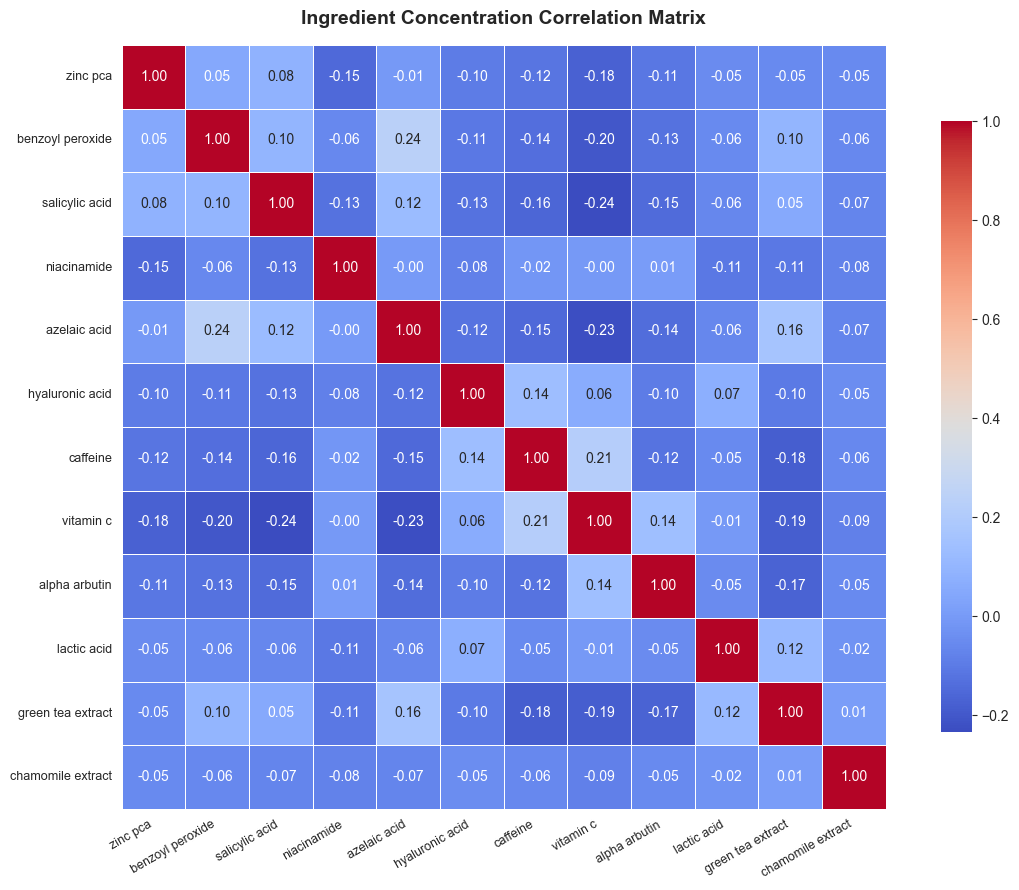

✅ Correlation heatmap saved.


In [ ]:
top_conc_cols = [f"conc_{c}" for c in conc_df.columns[:12]]
corr = df_features[top_conc_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            xticklabels=[c.replace('conc_', '').replace('_', ' ') for c in top_conc_cols],
            yticklabels=[c.replace('conc_', '').replace('_', ' ') for c in top_conc_cols])
plt.title('Ingredient Concentration Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('ingredient_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Correlation heatmap saved.')

In [ ]:
import pickle

df_features.to_csv('recommendation_features.csv', index=False)
print('✅ Saved: recommendation_features.csv')

df_labels.to_csv('recommendation_labels.csv', index=False)
print('✅ Saved: recommendation_labels.csv')

conc_df.to_csv('ingredient_concentrations_raw.csv', index=False)
print('✅ Saved: ingredient_concentrations_raw.csv')

with open('tfidf_ingredients.pkl', 'wb') as f:
    pickle.dump(tfidf_ing, f)
with open('tfidf_effects.pkl', 'wb') as f:
    pickle.dump(tfidf_eff, f)
with open('scaler_concentrations.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print('✅ Saved: tfidf_ingredients.pkl, tfidf_effects.pkl')
print('✅ Saved: scaler_concentrations.pkl, label_encoders.pkl')

print('\n' + '='*55)
print('  STEP 1 PREPROCESSING SUMMARY')
print('='*55)
print(f'  Total rows              : {len(df_features)}')
print(f'  Total feature columns   : {df_features.shape[1]}')
print(f'    - One-hot (cat)       : {df_ohe.shape[1]}')
print(f'    - Concentration (num) : {conc_scaled.shape[1]}  ← FIXED (was 0s)')
print(f'    - Ingredients TF-IDF  : {ingredients_df.shape[1]}')
print(f'    - Effects TF-IDF      : {effects_df.shape[1]}')
print(f'  NaN values              : 0')
print('='*55)
print('  ✅ Ready for Phase 3 — Model Architecture')
print('='*55)

✅ Saved: recommendation_features.csv
✅ Saved: recommendation_labels.csv
✅ Saved: ingredient_concentrations_raw.csv
✅ Saved: tfidf_ingredients.pkl, tfidf_effects.pkl
✅ Saved: scaler_concentrations.pkl, label_encoders.pkl

  STEP 1 PREPROCESSING SUMMARY
  Total rows              : 1120
  Total feature columns   : 159
    - One-hot (cat)       : 36
    - Concentration (num) : 23  ← FIXED (was 0s)
    - Ingredients TF-IDF  : 50
    - Effects TF-IDF      : 50
  NaN values              : 0
  ✅ Ready for Phase 3 — Model Architecture
